In [7]:
import os
import numpy as np
from pathlib import Path
import scipy.ndimage

import scipy.ndimage as ndi

def get_bounding_box(pet_array, ct_array, ct_thresh=-500):
    """
    Step 3 辅助函数: 基于连通域的最大 3D 边界框裁剪。
    针对 ViMedPET 的基线偏移，默认 ct_thresh 设为 500。
    """
    body_mask = ct_array > ct_thresh
    labels, num_features = ndi.label(body_mask)
    
    if num_features == 0:
        return None
        
    counts = np.bincount(labels.ravel())
    counts[0] = 0  
    largest_component_label = counts.argmax()
    clean_body_mask = (labels == largest_component_label)
    
    z_indices, y_indices, x_indices = np.where(clean_body_mask)
    if len(z_indices) == 0:
        return None
        
    z_min, z_max = z_indices.min(), z_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    x_min, x_max = x_indices.min(), x_indices.max()
    
    pad = 3
    z_min, z_max = max(0, z_min - pad), min(pet_array.shape[0], z_max + pad + 1)
    y_min, y_max = max(0, y_min - pad), min(pet_array.shape[1], y_max + pad + 1)
    x_min, x_max = max(0, x_min - pad), min(pet_array.shape[2], x_max + pad + 1)
    
    return slice(z_min, z_max), slice(y_min, y_max), slice(x_min, x_max)

def normalize_volume(volume, method='z-score'):
    """
    分别对数据进行归一化。
    参数 method 可以选 'z-score' (均值=0, 标准差=1) 或 'min-max' (缩放到 [0,1])。
    """
    if method == 'z-score':
        mu = np.mean(volume)
        sigma = np.std(volume)
        if sigma == 0:
            return volume - mu
        return (volume - mu) / sigma
    elif method == 'min-max':
        v_min = np.min(volume)
        v_max = np.max(volume)
        if v_max - v_min == 0:
            return volume - v_min
        return (volume - v_min) / (v_max - v_min)
    else:
        raise ValueError("不支持的归一化方法，请选择 'z-score' 或 'min-max'")

def process_spade_dataset():
    """
    针对 Spade 数据集的完整独立预处理流水线。
    """
    # 1. 定义源路径与目标保存路径
    source_base = Path('/data24/xl693/spade')
    target_base = Path('/gluon4/xl693/PETCTfoundation/Spade')
    
    # Z=3, Y=3.5., X=3.5. (NumPy 维度顺序为 Z, Y, X)
    orig_spacing = np.array([3, 3.5, 3.5])
    target_spacing = np.array([3.0, 2.0, 2.0])
    
    print(f"开始处理 Spade 数据集...")
    print(f"源目录: {source_base}")
    print(f"输出目录: {target_base}\n")
    
    # 2. 遍历两层文件夹 (PatientID -> ScanID)
    if not source_base.exists():
        print(f"错误: 找不到源文件夹 {source_base}")
        return

    # 遍历病人层级
    for patient_dir in sorted(source_base.iterdir()):
        if not patient_dir.is_dir():
            continue
            
        # 遍历扫描层级
        for scan_dir in sorted(patient_dir.iterdir()):
            if not scan_dir.is_dir():
                continue
                
            pet_path = scan_dir / 'pet.npy'
            ct_path = scan_dir / 'ct.npy'
            
            # 只有当 pet.npy 和 ct.npy 成对存在时才处理
            if pet_path.exists() and ct_path.exists():
                try:
                    print(f"处理数据: {patient_dir.name}/{scan_dir.name}")
                    
                    # ---------------- 数据加载与重采样 ----------------
                    pet = np.load(pet_path).astype(np.float32)
                    ct = np.load(ct_path).astype(np.float32)
                    
                    # 步骤 1: 将 PET 统一 space 到 2mmx2mmx2mm
                    zoom_factors_pet = orig_spacing / target_spacing
                    pet_resampled = scipy.ndimage.zoom(pet, zoom_factors_pet, order=1)
                    
                    # 步骤 2: resize CT 的 size 到 PET
                    # 使用插值后的 PET 形状除以原始 CT 形状，确保最终 shape 完美一致
                    zoom_factors_ct = np.array(pet_resampled.shape) / np.array(ct.shape)
                    ct_resampled = scipy.ndimage.zoom(ct, zoom_factors_ct, order=1)
                    
                    # 步骤 3: 去除空白区域，减小尺寸
                    bbox = get_bounding_box(pet_resampled, ct_resampled, ct_thresh=-500)
                    if bbox is not None:
                        pet_cropped = pet_resampled[bbox]
                        ct_cropped = ct_resampled[bbox]
                    else:
                        pet_cropped, ct_cropped = pet_resampled, ct_resampled   
                        
                    # 步骤 4: 分别对 CT 或 PET 数据进行 Z-score standardization 归一化
                    # 这里默认使用 z-score, 如需映射到 [0, 1], 将 'z-score' 改为 'min-max'
                    pet_norm = normalize_volume(pet_cropped, method='z-score')
                    ct_norm = normalize_volume(ct_cropped, method='z-score')
                    
                    # 步骤 2 (续): concatenent 同样大小的 PET 和 CT 到两个 channel
                    # 最终形状为 (2, Z, Y, X), Channel 0 是 PET，Channel 1 是 CT
                    stacked_volume = np.stack([pet_norm, ct_norm], axis=0)
                    
                    # 步骤 5: 保持原路径结构保存为 npy 文件
                    # 相对路径为 PatientID/ScanID/pet.npy
                    relative_path = pet_path.relative_to(source_base)
                    save_path = target_base / relative_path
                    
                    # 确保保存路径所在的文件夹存在
                    save_path.parent.mkdir(parents=True, exist_ok=True)
                    
                    # 保存并打印成功信息
                    np.save(save_path, stacked_volume)
                    print(f"  -> 成功保存至: {save_path}")
                    print(f"  -> 最终 Tensor 形状: {stacked_volume.shape}\n")
                    
                except Exception as e:
                    print(f"  -> [错误] 处理 {scan_dir} 时发生异常: {e}\n")

if __name__ == '__main__':
    process_spade_dataset()
    print("Spade 数据集处理完毕。")

开始处理 Spade 数据集...
源目录: /data24/xl693/spade
输出目录: /gluon4/xl693/PETCTfoundation/Spade

处理数据: LDca4b18/LDca4b79
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b18/LDca4b79/pet.npy
  -> 最终 Tensor 形状: (2, 205, 224, 224)

处理数据: LDca4b18/LDca4b7a
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b18/LDca4b7a/pet.npy
  -> 最终 Tensor 形状: (2, 171, 224, 224)

处理数据: LDca4b19/LDca4b83
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b19/LDca4b83/pet.npy
  -> 最终 Tensor 形状: (2, 239, 224, 224)

处理数据: LDca4b1c/LDca4b70
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b1c/LDca4b70/pet.npy
  -> 最终 Tensor 形状: (2, 205, 224, 224)

处理数据: LDca4b1f/LDca4b71
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b1f/LDca4b71/pet.npy
  -> 最终 Tensor 形状: (2, 205, 224, 224)

处理数据: LDca4b1f/LDca4b72
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b1f/LDca4b72/pet.npy
  -> 最终 Tensor 形状: (2, 239, 224, 224)

处理数据: LDca4b1f/LDca4b73
  -> 成功保存至: /gluon4/xl693/PETCTfoundation/Spade/LDca4b1f/LDca4b73/pe

Loading Patient LDca4b1f - Scan 72...
Loading Patient LDca4b3a - Scan 80...


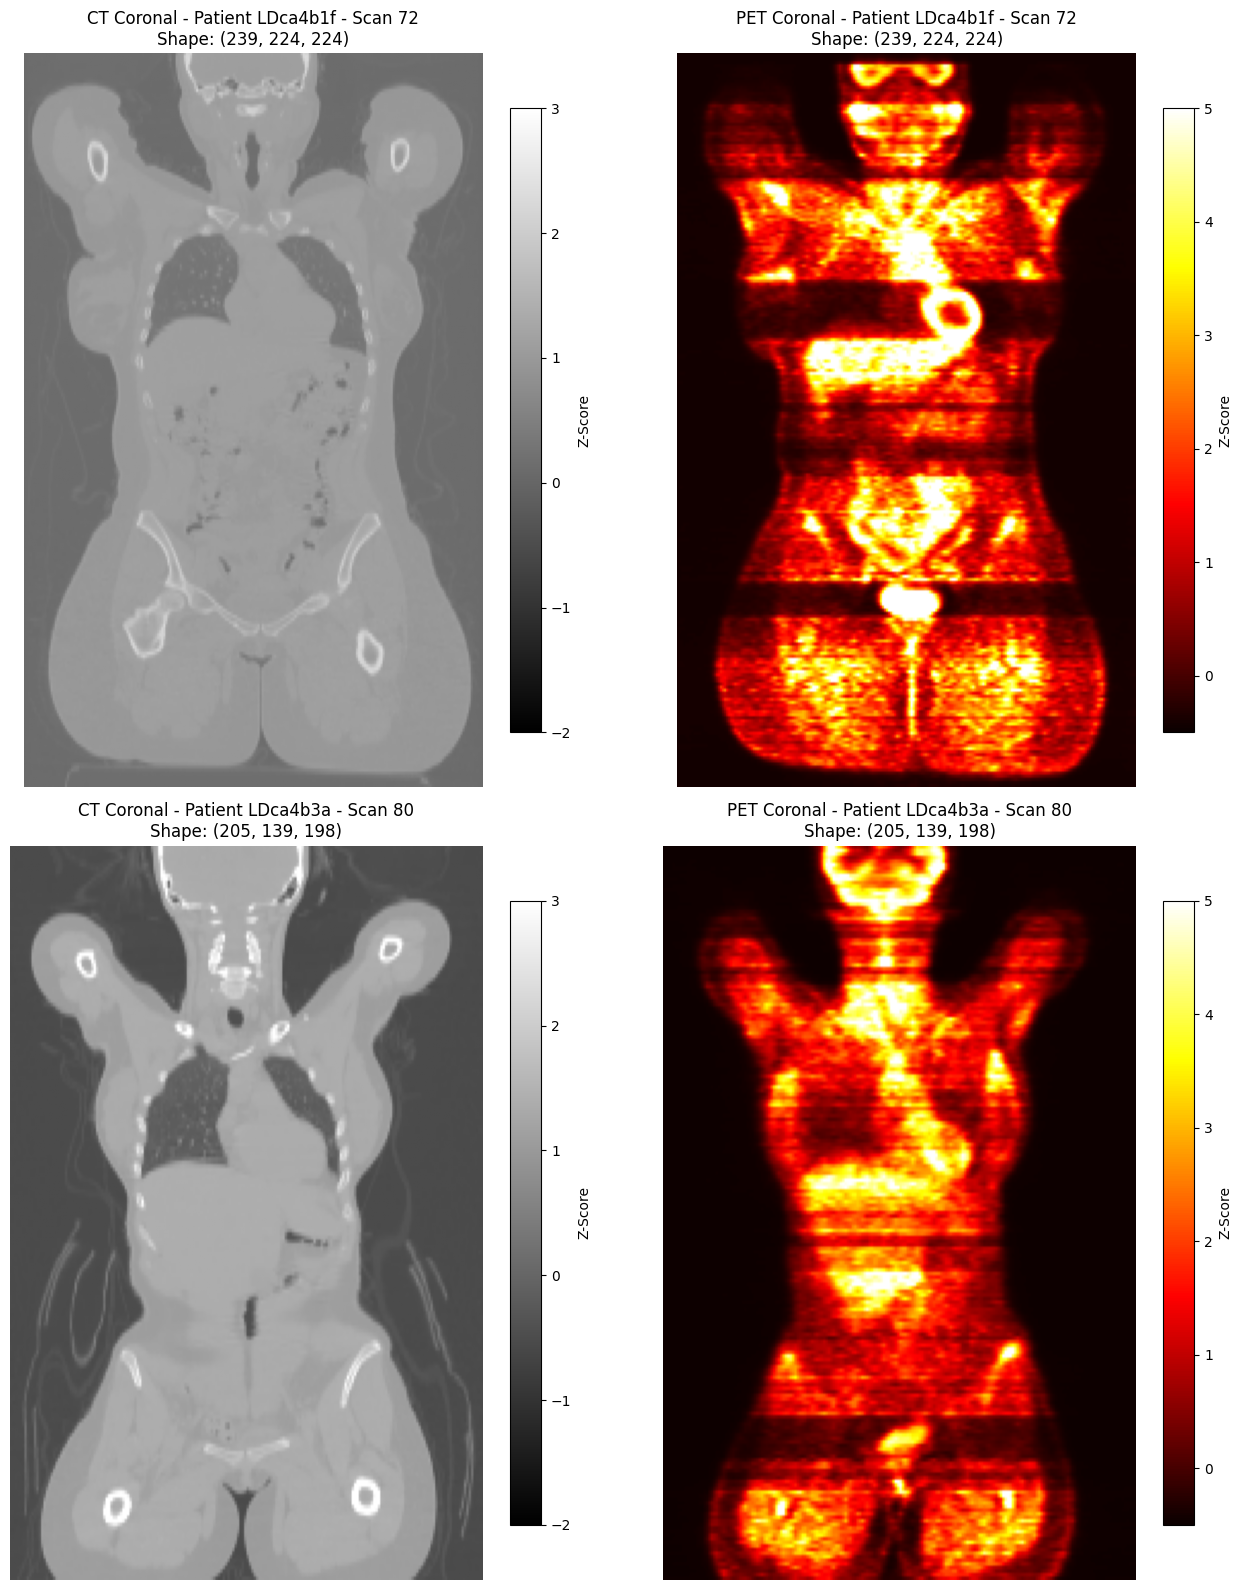

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_spade_processed_samples():
    # 从您的日志中选取两个具有代表性的全身体积样本
    base_dir = '/gluon4/xl693/PETCTfoundation/Spade'
    sample1_path = f'{base_dir}/LDca4b1f/LDca4b72/pet.npy'
    sample2_path = f'{base_dir}/LDca4ba0/LDcb15d0/pet.npy'
    
    paths = [sample1_path, sample2_path]
    titles = ['Patient LDca4b1f - Scan 72', 'Patient LDca4b3a - Scan 80']
    
    # 目标分辨率为 (Z=3, Y=2, X=2)，故纵向显示的 Aspect Ratio = 3.0/2.0 = 1.5
    display_aspect = 1.5 
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 16))
    
    for i, path in enumerate(paths):
        print(f"Loading {titles[i]}...")
        # 加载形状为 (C, Z, Y, X) 的张量
        data = np.load(path)
        
        # 提取冠状面 (Coronal Plane)：沿 Y 轴中点切片
        y_mid = data.shape[2] // 2
        pet_coronal = data[0, :, y_mid, :]
        ct_coronal = data[1, :, y_mid, :]
        
        # -------- 绘制 CT (左列) --------
        ax_ct = axes[i, 0]
        # Z-score 数据：vmin=-2, vmax=3 适合观察软组织
        im_ct = ax_ct.imshow(ct_coronal, cmap='gray', origin='lower', aspect=display_aspect, vmin=-2, vmax=3)
        ax_ct.set_title(f"CT Coronal - {titles[i]}\nShape: {data.shape[1:]}")
        ax_ct.axis('off')
        fig.colorbar(im_ct, ax=ax_ct, fraction=0.046, pad=0.04, label='Z-Score')
        
        # -------- 绘制 PET (右列) --------
        ax_pet = axes[i, 1]
        # Z-score 数据：vmin=-0.5, vmax=5 适合观察代谢热点
        im_pet = ax_pet.imshow(pet_coronal, cmap='hot', origin='lower', aspect=display_aspect, vmin=-0.5, vmax=5)
        ax_pet.set_title(f"PET Coronal - {titles[i]}\nShape: {data.shape[1:]}")
        ax_pet.axis('off')
        fig.colorbar(im_pet, ax=ax_pet, fraction=0.046, pad=0.04, label='Z-Score')
        
    plt.tight_layout()
    plt.show()

# 执行可视化
visualize_spade_processed_samples()

In [1]:
import os
from pathlib import Path
import numpy as np

def analyze_dataset_dimensions():
    base_path = Path('/gluon4/xl693/PETCTfoundation/')
    
    if not base_path.exists():
        print(f"Error: Path {base_path} does not exist.")
        return

    print(f"Scanning dataset dimensions in: {base_path}")
    print("=" * 60)
    
    # Iterate through each dataset directory
    for dataset_dir in sorted(base_path.iterdir()):
        if not dataset_dir.is_dir():
            continue
            
        npy_files = list(dataset_dir.rglob('*.npy'))
        if not npy_files:
            continue
            
        # Initialize Min (infinity) and Max (0) for Z, Y, X
        min_z, min_y, min_x = float('inf'), float('inf'), float('inf')
        max_z, max_y, max_x = 0, 0, 0
        
        valid_files = 0
        
        for f in npy_files:
            try:
                # mmap_mode='r' instantly reads ONLY the file header to get the shape
                shape = np.load(f, mmap_mode='r').shape
                
                # Ensure the shape is exactly (Channels, Z, Y, X)
                if len(shape) == 4:
                    c, z, y, x = shape
                    
                    # Update Minimums
                    min_z = min(min_z, z)
                    min_y = min(min_y, y)
                    min_x = min(min_x, x)
                    
                    # Update Maximums
                    max_z = max(max_z, z)
                    max_y = max(max_y, y)
                    max_x = max(max_x, x)
                    
                    valid_files += 1
            except Exception as e:
                print(f"  [Error] Failed reading {f.name}: {e}")
                
        # Print the statistics for this dataset
        if valid_files > 0:
            print(f"Dataset: {dataset_dir.name:<12} | Valid Tensors: {valid_files}")
            print(f"  -> Z-axis (Slice): Min = {min_z:>4}, Max = {max_z:>4}")
            print(f"  -> Y-axis (H)    : Min = {min_y:>4}, Max = {max_y:>4}")
            print(f"  -> X-axis (W)    : Min = {min_x:>4}, Max = {max_x:>4}")
            print("-" * 60)

if __name__ == '__main__':
    analyze_dataset_dimensions()

Scanning dataset dimensions in: /gluon4/xl693/PETCTfoundation
Dataset: AutoPET      | Valid Tensors: 1014
  -> Z-axis (Slice): Min =  200, Max =  661
  -> Y-axis (H)    : Min =  122, Max =  235
  -> X-axis (W)    : Min =  179, Max =  251
------------------------------------------------------------
Dataset: DeepPSMA     | Valid Tensors: 100
  -> Z-axis (Slice): Min =  296, Max =  608
  -> Y-axis (H)    : Min =  151, Max =  293
  -> X-axis (W)    : Min =  196, Max =  369
------------------------------------------------------------
Dataset: Spade        | Valid Tensors: 1137
  -> Z-axis (Slice): Min =    1, Max =  307
  -> Y-axis (H)    : Min =   62, Max =  224
  -> X-axis (W)    : Min =   65, Max =  224
------------------------------------------------------------
Dataset: ViMedPET     | Valid Tensors: 2757
  -> Z-axis (Slice): Min =  207, Max =  551
  -> Y-axis (H)    : Min =  104, Max =  245
  -> X-axis (W)    : Min =  167, Max =  256
----------------------------------------------------

Searching for anomalous tensors (Z <= 5)...
Found 11 anomalous files!
Loading anomaly: /gluon4/xl693/PETCTfoundation/Spade/LDca4f40/LDca5687/pet.npy
Shape: (2, 1, 85, 158)


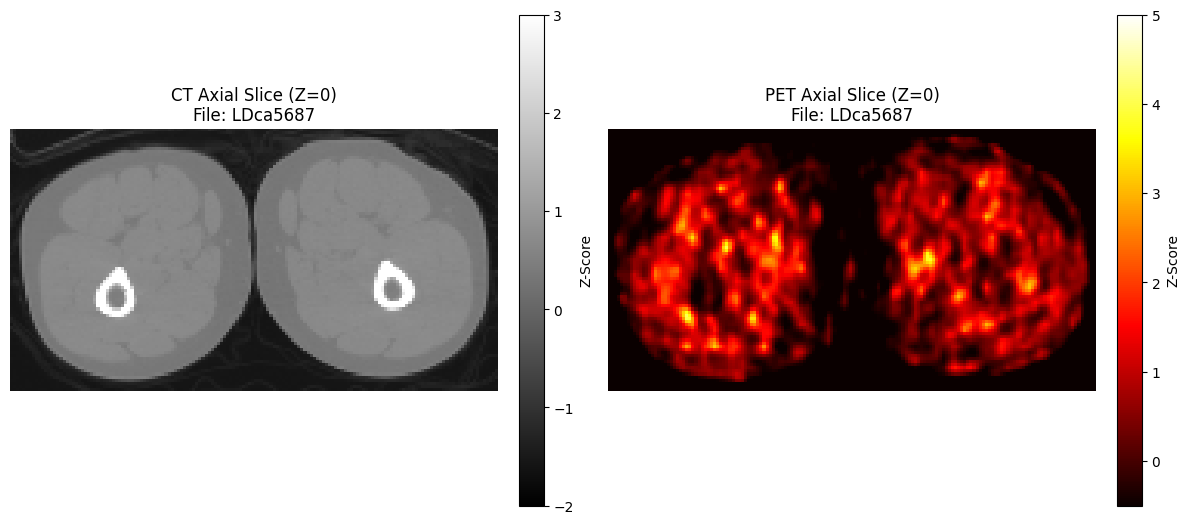


Other anomalous files found:
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca56d5/LDca5e13/pet.npy | Shape: (2, 1, 108, 83)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca4eed/LDca54ed/pet.npy | Shape: (2, 1, 92, 155)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca519f/LDca5602/pet.npy | Shape: (2, 1, 87, 151)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca56da/LDca5d8b/pet.npy | Shape: (2, 1, 62, 68)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca58c7/LDca5c77/pet.npy | Shape: (2, 1, 67, 65)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca58c3/LDca5c6f/pet.npy | Shape: (2, 1, 62, 77)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca4f3f/LDca5507/pet.npy | Shape: (2, 1, 90, 187)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca58c2/LDca5c6e/pet.npy | Shape: (2, 1, 71, 77)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca5163/LDca5581/pet.npy | Shape: (2, 1, 66, 142)
  -> /gluon4/xl693/PETCTfoundation/Spade/LDca56d2/LDca5d2b/pet.npy | Shape: (2, 1, 78, 153)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def find_and_visualize_z1_anomaly():
    base_dir = Path('/gluon4/xl693/PETCTfoundation/Spade')
    
    print("Searching for anomalous tensors (Z <= 5)...")
    anomaly_paths = []
    
    # 1. Search for the anomaly using memory mapping (extremely fast)
    for npy_file in base_dir.rglob('*.npy'):
        try:
            shape = np.load(npy_file, mmap_mode='r').shape
            if shape[1] <= 5:  # Looking for Z=1, but catching any extremely thin slices
                anomaly_paths.append((npy_file, shape))
        except Exception as e:
            continue
            
    if not anomaly_paths:
        print("No anomalies found with Z <= 5.")
        return
        
    print(f"Found {len(anomaly_paths)} anomalous files!")
    
    # 2. Visualize the first anomaly found
    target_file, target_shape = anomaly_paths[0]
    print(f"Loading anomaly: {target_file}")
    print(f"Shape: {target_shape}")
    
    # Load the full array
    data = np.load(target_file)
    
    # Since Z is very small (likely 1), we plot the middle (or only) Axial slice
    z_mid = data.shape[1] // 2
    pet_axial = data[0, z_mid, :, :]
    ct_axial = data[1, z_mid, :, :]
    
    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # CT Plot
    ax_ct = axes[0]
    im_ct = ax_ct.imshow(ct_axial, cmap='gray', origin='lower', vmin=-2, vmax=3)
    ax_ct.set_title(f"CT Axial Slice (Z={z_mid})\nFile: {target_file.parent.name}")
    ax_ct.axis('off')
    fig.colorbar(im_ct, ax=ax_ct, fraction=0.046, pad=0.04, label='Z-Score')
    
    # PET Plot
    ax_pet = axes[1]
    im_pet = ax_pet.imshow(pet_axial, cmap='hot', origin='lower', vmin=-0.5, vmax=5)
    ax_pet.set_title(f"PET Axial Slice (Z={z_mid})\nFile: {target_file.parent.name}")
    ax_pet.axis('off')
    fig.colorbar(im_pet, ax=ax_pet, fraction=0.046, pad=0.04, label='Z-Score')
    
    plt.tight_layout()
    plt.show()
    
    # Print the rest if there are more
    if len(anomaly_paths) > 1:
        print("\nOther anomalous files found:")
        for p, s in anomaly_paths[1:]:
            print(f"  -> {p} | Shape: {s}")

# Execute the anomaly hunter
find_and_visualize_z1_anomaly()

Checking RAW shapes for the 11 anomalous files...
LDca4f40/LDca5687    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca56d5/LDca5e13    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca4eed/LDca54ed    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca519f/LDca5602    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca56da/LDca5d8b    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca58c7/LDca5c77    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca58c3/LDca5c6f    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca4f3f/LDca5507    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca58c2/LDca5c6e    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca5163/LDca5581    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)
LDca56d2/LDca5d2b    | RAW CT: (1, 512, 512)   | RAW PET: (1, 128, 128)

Visualizing Raw Data for: LDca4f40/LDca5687


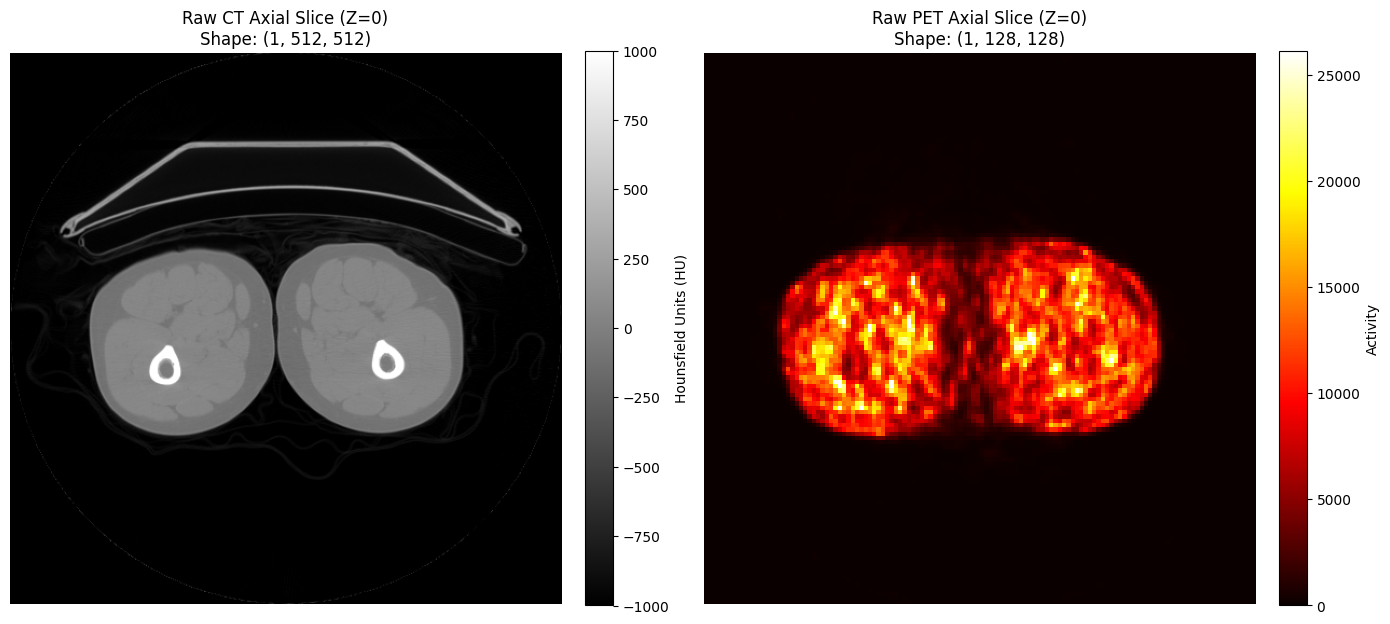

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def analyze_raw_spade_anomalies():
    # Define the original source directory for Spade
    source_base = Path('/data24/xl693/spade')
    
    # The 11 anomalous relative paths extracted from your log
    anomalies = [
        'LDca4f40/LDca5687',
        'LDca56d5/LDca5e13',
        'LDca4eed/LDca54ed',
        'LDca519f/LDca5602',
        'LDca56da/LDca5d8b',
        'LDca58c7/LDca5c77',
        'LDca58c3/LDca5c6f',
        'LDca4f3f/LDca5507',
        'LDca58c2/LDca5c6e',
        'LDca5163/LDca5581',
        'LDca56d2/LDca5d2b'
    ]
    
    print("Checking RAW shapes for the 11 anomalous files...")
    print("=" * 70)
    
    raw_shapes = []
    
    # 1. Print all raw shapes
    for rel_path in anomalies:
        # Assuming the standard naming in your Spade dataset (try both lower and upper case)
        ct_path = source_base / rel_path / 'ct.npy'
        pet_path = source_base / rel_path / 'pet.npy'
        
        if not ct_path.exists(): ct_path = source_base / rel_path / 'CT.npy'
        if not pet_path.exists(): pet_path = source_base / rel_path / 'PET.npy'
        
        if ct_path.exists() and pet_path.exists():
            # Read only the headers for speed
            raw_ct_shape = np.load(ct_path, mmap_mode='r').shape
            raw_pet_shape = np.load(pet_path, mmap_mode='r').shape
            print(f"{rel_path:<20} | RAW CT: {str(raw_ct_shape):<15} | RAW PET: {raw_pet_shape}")
            raw_shapes.append((ct_path, pet_path))
        else:
            print(f"{rel_path:<20} | [Error] Raw files not found.")
            
    print("=" * 70)
    
    # 2. Visualize the first anomalous pair
    if raw_shapes:
        ct_path, pet_path = raw_shapes[0]
        patient_id = ct_path.parent.relative_to(source_base)
        
        print(f"\nVisualizing Raw Data for: {patient_id}")
        
        # Load the full raw arrays
        raw_ct = np.load(ct_path)
        raw_pet = np.load(pet_path)
        
        # Get the middle Z-slice
        z_mid_ct = raw_ct.shape[0] // 2
        z_mid_pet = raw_pet.shape[0] // 2
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        
        # Plot Raw CT (Using standard Hounsfield Unit window: -1000 to 1000)
        ax_ct = axes[0]
        im_ct = ax_ct.imshow(raw_ct[z_mid_ct], cmap='gray', origin='lower', vmin=-1000, vmax=1000)
        ax_ct.set_title(f"Raw CT Axial Slice (Z={z_mid_ct})\nShape: {raw_ct.shape}")
        ax_ct.axis('off')
        fig.colorbar(im_ct, ax=ax_ct, fraction=0.046, pad=0.04, label='Hounsfield Units (HU)')
        
        # Plot Raw PET
        ax_pet = axes[1]
        im_pet = ax_pet.imshow(raw_pet[z_mid_pet], cmap='hot', origin='lower', vmin=0, vmax=np.percentile(raw_pet, 99.9))
        ax_pet.set_title(f"Raw PET Axial Slice (Z={z_mid_pet})\nShape: {raw_pet.shape}")
        ax_pet.axis('off')
        fig.colorbar(im_pet, ax=ax_pet, fraction=0.046, pad=0.04, label='Activity')
        
        plt.tight_layout()
        plt.show()

# Execute the diagnostic code
analyze_raw_spade_anomalies()

In [4]:
import os
from pathlib import Path
import numpy as np

def analyze_dataset_dimensions():
    base_path = Path('/gluon4/xl693/PETCTfoundation/')
    
    # List of known corrupted/anomalous scans to skip
    anomalies = [
        'LDca4f40/LDca5687',
        'LDca56d5/LDca5e13',
        'LDca4eed/LDca54ed',
        'LDca519f/LDca5602',
        'LDca56da/LDca5d8b',
        'LDca58c7/LDca5c77',
        'LDca58c3/LDca5c6f',
        'LDca4f3f/LDca5507',
        'LDca58c2/LDca5c6e',
        'LDca5163/LDca5581',
        'LDca56d2/LDca5d2b'
    ]
    
    if not base_path.exists():
        print(f"Error: Path {base_path} does not exist.")
        return

    print(f"Scanning dataset dimensions in: {base_path}")
    print(f"Excluding {len(anomalies)} known anomalous samples.")
    print("=" * 60)
    
    # Iterate through each dataset directory
    for dataset_dir in sorted(base_path.iterdir()):
        if not dataset_dir.is_dir():
            continue
            
        npy_files = list(dataset_dir.rglob('*.npy'))
        if not npy_files:
            continue
            
        # Initialize Min (infinity) and Max (0) for Z, Y, X
        min_z, min_y, min_x = float('inf'), float('inf'), float('inf')
        max_z, max_y, max_x = 0, 0, 0
        
        valid_files = 0
        
        for f in npy_files:
            # Check if the current file path contains any of the anomaly strings
            if any(anomaly in f.as_posix() for anomaly in anomalies):
                continue  # Skip this anomalous file
                
            try:
                # mmap_mode='r' instantly reads ONLY the file header to get the shape
                shape = np.load(f, mmap_mode='r').shape
                
                # Ensure the shape is exactly (Channels, Z, Y, X)
                if len(shape) == 4:
                    c, z, y, x = shape
                    
                    # Update Minimums
                    min_z = min(min_z, z)
                    min_y = min(min_y, y)
                    min_x = min(min_x, x)
                    
                    # Update Maximums
                    max_z = max(max_z, z)
                    max_y = max(max_y, y)
                    max_x = max(max_x, x)
                    
                    valid_files += 1
            except Exception as e:
                print(f"  [Error] Failed reading {f.name}: {e}")
                
        # Print the statistics for this dataset
        if valid_files > 0:
            print(f"Dataset: {dataset_dir.name:<12} | Valid Tensors: {valid_files}")
            print(f"  -> Z-axis (Slice): Min = {min_z:>4}, Max = {max_z:>4}")
            print(f"  -> Y-axis (H)    : Min = {min_y:>4}, Max = {max_y:>4}")
            print(f"  -> X-axis (W)    : Min = {min_x:>4}, Max = {max_x:>4}")
            print("-" * 60)

if __name__ == '__main__':
    analyze_dataset_dimensions()

Scanning dataset dimensions in: /gluon4/xl693/PETCTfoundation
Excluding 11 known anomalous samples.
Dataset: AutoPET      | Valid Tensors: 1014
  -> Z-axis (Slice): Min =  200, Max =  661
  -> Y-axis (H)    : Min =  122, Max =  235
  -> X-axis (W)    : Min =  179, Max =  251
------------------------------------------------------------
Dataset: DeepPSMA     | Valid Tensors: 100
  -> Z-axis (Slice): Min =  296, Max =  608
  -> Y-axis (H)    : Min =  151, Max =  293
  -> X-axis (W)    : Min =  196, Max =  369
------------------------------------------------------------
Dataset: Spade        | Valid Tensors: 1126
  -> Z-axis (Slice): Min =  103, Max =  307
  -> Y-axis (H)    : Min =  109, Max =  224
  -> X-axis (W)    : Min =  141, Max =  224
------------------------------------------------------------
Dataset: ViMedPET     | Valid Tensors: 2757
  -> Z-axis (Slice): Min =  207, Max =  551
  -> Y-axis (H)    : Min =  104, Max =  245
  -> X-axis (W)    : Min =  167, Max =  256
--------------